# hello

In [50]:
!nvidia-smi

Thu Apr 16 05:14:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P0             30W /   70W |     109MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [51]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [52]:
%%writefile hello.cu
#include <stdio.h>
#include <cuda_runtime.h>

__global__ void hello() {
    printf("Hello from CUDA thread %d\n", threadIdx.x);
}

int main() {
    hello<<<1, 5>>>();
    cudaDeviceSynchronize();
    return 0;
}

Overwriting hello.cu


In [53]:
!nvcc hello.cu -o hello

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [54]:
!./hello

Hello from CUDA thread 0
Hello from CUDA thread 1
Hello from CUDA thread 2
Hello from CUDA thread 3
Hello from CUDA thread 4


# Parallel Reduction

In [55]:
!nvidia-smi

Thu Apr 16 05:14:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P0             31W /   70W |     109MiB /  15360MiB |      4%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [56]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [57]:
%%writefile reduction.cu
#include <stdio.h>
#include <cuda_runtime.h>

#define N 1024
#define THREADS 512

__global__ void reduction(int *input, int *output) {
    __shared__ int shared[THREADS];

    int tid = threadIdx.x;
    int idx = blockIdx.x * blockDim.x + threadIdx.x;

    shared[tid] = input[idx];
    __syncthreads();

    for (int stride = blockDim.x / 2; stride > 0; stride >>= 1) {
        if (tid < stride) {
            shared[tid] += shared[tid + stride];
        }
        __syncthreads();
    }

    if (tid == 0) {
        output[blockIdx.x] = shared[0];
    }
}

int main() {
    int h_input[N];
    int h_output[N / THREADS];

    for (int i = 0; i < N; i++) {
        h_input[i] = 1;
    }

    int *d_input, *d_output;
    cudaMalloc((void**)&d_input, N * sizeof(int));
    cudaMalloc((void**)&d_output, (N / THREADS) * sizeof(int));

    cudaMemcpy(d_input, h_input, N * sizeof(int), cudaMemcpyHostToDevice);

    reduction<<<N / THREADS, THREADS>>>(d_input, d_output);

    cudaMemcpy(h_output, d_output,
               (N / THREADS) * sizeof(int),
               cudaMemcpyDeviceToHost);

    int final_sum = 0;
    for (int i = 0; i < N / THREADS; i++) {
        final_sum += h_output[i];
    }

    printf("Final sum using CUDA Parallel Reduction = %d\n", final_sum);

    cudaFree(d_input);
    cudaFree(d_output);

    return 0;
}

Overwriting reduction.cu


In [58]:
!nvcc reduction.cu -o reduction

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [59]:
!./reduction

Final sum using CUDA Parallel Reduction = 1024


# Vector Addition

In [60]:
%%writefile vector_add.cu
#include <stdio.h>
#include <cuda_runtime.h>

__global__ void vectorAdd(int *A, int *B, int *C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N)
        C[i] = A[i] + B[i];
}

int main(int argc, char *argv[]) {
    int N = atoi(argv[1]);
    int size = N * sizeof(int);

    int *hA = (int*)malloc(size);
    int *hB = (int*)malloc(size);
    int *hC = (int*)malloc(size);

    for (int i = 0; i < N; i++) {
        hA[i] = i;
        hB[i] = i;
    }

    int *dA, *dB, *dC;
    cudaMalloc(&dA, size);
    cudaMalloc(&dB, size);
    cudaMalloc(&dC, size);

    cudaMemcpy(dA, hA, size, cudaMemcpyHostToDevice);
    cudaMemcpy(dB, hB, size, cudaMemcpyHostToDevice);

    int threads = 256;
    int blocks = (N + threads - 1) / threads;

    vectorAdd<<<blocks, threads>>>(dA, dB, dC, N);

    cudaMemcpy(hC, dC, size, cudaMemcpyDeviceToHost);

    printf("Vector Add (first 10): ");
    for (int i = 0; i < 10 && i < N; i++)
        printf("%d ", hC[i]);
    printf("\n");

    return 0;
}

Overwriting vector_add.cu


In [61]:
!nvcc vector_add.cu -o vector_add

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [62]:
!./vector_add 1000

Vector Add (first 10): 0 2 4 6 8 10 12 14 16 18 


# Array Reversal

In [63]:
%%writefile array_reverse.cu
#include <stdio.h>
#include <cuda_runtime.h>

__global__ void reverseArray(int *A, int *B, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N)
        B[N - i - 1] = A[i];
}

int main(int argc, char *argv[]) {
    int N = atoi(argv[1]);
    int size = N * sizeof(int);

    int *hA = (int*)malloc(size);
    int *hB = (int*)malloc(size);

    for (int i = 0; i < N; i++)
        hA[i] = i;

    int *dA, *dB;
    cudaMalloc(&dA, size);
    cudaMalloc(&dB, size);

    cudaMemcpy(dA, hA, size, cudaMemcpyHostToDevice);

    int threads = 256;
    int blocks = (N + threads - 1) / threads;

    reverseArray<<<blocks, threads>>>(dA, dB, N);
    cudaMemcpy(hB, dB, size, cudaMemcpyDeviceToHost);

    printf("Reversed (first 10): ");
    for (int i = 0; i < 10 && i < N; i++)
        printf("%d ", hB[i]);
    printf("\n");

    return 0;
}

Overwriting array_reverse.cu


In [64]:
!nvcc array_reverse.cu -o array_reverse
!./array_reverse 20

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Reversed (first 10): 19 18 17 16 15 14 13 12 11 10 


# Element-wise Vector operations

In [65]:
%%writefile vector_ops.cu
#include <stdio.h>
#include <cuda_runtime.h>

__global__ void vectorOps(int *A, int *B, int *C, int N, int op) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) {
        if (op == 1) C[i] = A[i] * 2;
        else if (op == 2) C[i] = A[i] * A[i];
        else if (op == 3) C[i] = A[i] - B[i];
    }
}

int main(int argc, char *argv[]) {
    int N = atoi(argv[1]);
    int op = atoi(argv[2]);
    int size = N * sizeof(int);

    int *hA = (int*)malloc(size);
    int *hB = (int*)malloc(size);
    int *hC = (int*)malloc(size);

    for (int i = 0; i < N; i++) {
        hA[i] = i;
        hB[i] = i / 2;
    }

    int *dA, *dB, *dC;
    cudaMalloc(&dA, size);
    cudaMalloc(&dB, size);
    cudaMalloc(&dC, size);

    cudaMemcpy(dA, hA, size, cudaMemcpyHostToDevice);
    cudaMemcpy(dB, hB, size, cudaMemcpyHostToDevice);

    int threads = 256;
    int blocks = (N + threads - 1) / threads;

    vectorOps<<<blocks, threads>>>(dA, dB, dC, N, op);
    cudaMemcpy(hC, dC, size, cudaMemcpyDeviceToHost);

    printf("Result (first 10): ");
    for (int i = 0; i < 10 && i < N; i++)
        printf("%d ", hC[i]);
    printf("\n");

    return 0;
}


Overwriting vector_ops.cu


In [66]:
!nvcc vector_ops.cu -o vector_ops
!./vector_ops 1000 1   # scale
!./vector_ops 1000 2   # square
!./vector_ops 1000 3   # subtract

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Result (first 10): 0 2 4 6 8 10 12 14 16 18 
Result (first 10): 0 1 4 9 16 25 36 49 64 81 
Result (first 10): 0 1 1 2 2 3 3 4 4 5 


# Image Processing

In [67]:
!nvidia-smi

Thu Apr 16 05:14:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P0             38W /   70W |     109MiB /  15360MiB |      4%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [68]:
!pip install pillow matplotlib

In [69]:
from google.colab import files
uploaded = files.upload()

Saving input.jpg to input (1).jpg


In [70]:
!ls

 array_reverse	    image.png	       reduction	   vector_add.cu
 array_reverse.cu  'input (1).jpg'     reduction.cu	   vector_ops
 grayscale	    input.jpg	       sample_data	   vector_ops.cu
 grayscale.cu	    libmotion.so       stb_image.h
 hello		    motion_detect.cu   stb_image_write.h
 hello.cu	    output_gray.png    vector_add


In [71]:
!wget https://raw.githubusercontent.com/nothings/stb/master/stb_image.h
!wget https://raw.githubusercontent.com/nothings/stb/master/stb_image_write.h

--2026-04-16 05:15:46--  https://raw.githubusercontent.com/nothings/stb/master/stb_image.h
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 283010 (276K) [text/plain]
Saving to: ‘stb_image.h.1’

stb_image.h.1       100%[===================>] 276.38K  --.-KB/s    in 0.03s   

2026-04-16 05:15:46 (8.60 MB/s) - ‘stb_image.h.1’ saved [283010/283010]

--2026-04-16 05:15:46--  https://raw.githubusercontent.com/nothings/stb/master/stb_image_write.h
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 71221 (70K) [text/plain]
Saving to: ‘stb_im

In [72]:
%%writefile grayscale.cu
#include <stdio.h>
#include <cuda_runtime.h>

#define STB_IMAGE_IMPLEMENTATION
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "stb_image.h"
#include "stb_image_write.h"

__global__ void rgb2gray(unsigned char *input,
                         unsigned char *output,
                         int width, int height) {

    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x < width && y < height) {
        int rgb_idx = (y * width + x) * 3;
        int gray_idx = y * width + x;

        unsigned char r = input[rgb_idx];
        unsigned char g = input[rgb_idx + 1];
        unsigned char b = input[rgb_idx + 2];

        output[gray_idx] =
            (unsigned char)(0.299f*r + 0.587f*g + 0.114f*b);
    }
}

int main() {
    int width, height, channels;

    unsigned char *h_img =
        stbi_load("input.jpg", &width, &height, &channels, 3);

    if (!h_img) {
        printf("Failed to load image\n");
        return 1;
    }

    int img_size = width * height * 3;
    int gray_size = width * height;

    unsigned char *h_gray =
        (unsigned char*)malloc(gray_size);

    unsigned char *d_img, *d_gray;
    cudaMalloc(&d_img, img_size);
    cudaMalloc(&d_gray, gray_size);

    cudaMemcpy(d_img, h_img, img_size,
               cudaMemcpyHostToDevice);

    dim3 threads(16, 16);
    dim3 blocks((width + 15)/16,
                (height + 15)/16);

    rgb2gray<<<blocks, threads>>>(
        d_img, d_gray, width, height);

    cudaDeviceSynchronize();

    cudaMemcpy(h_gray, d_gray, gray_size,
               cudaMemcpyDeviceToHost);

    stbi_write_png("output_gray.png",
                   width, height, 1,
                   h_gray, width);

    cudaFree(d_img);
    cudaFree(d_gray);
    stbi_image_free(h_img);
    free(h_gray);

    printf("Grayscale image saved as output_gray.png\n");
    return 0;
}

Overwriting grayscale.cu


In [73]:
!nvcc grayscale.cu -o grayscale

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
stb_image.h(4276): warning #550-D: variable "old_limit" was set but never used
     unsigned int cur, limit, old_limit;
                              ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

stb_image.h(5185): warning #550-D: variable "idata_limit_old" was set but never used
                 stbi__uint32 idata_limit_old = idata_limit;
                              ^

stb_image.h(6972): warning #550-D: variable "out_size" was set but never used
        int out_size = 0;
            ^

stb_image.h(6973): warning #550-D: variable "delays_size" was set but never used
        int delays_size = 0;
            ^



In [74]:
!./grayscale

Grayscale image saved as output_gray.png


In [75]:
from PIL import Image
import numpy as np

# Create a simple RGB test image
img = np.zeros((256, 256, 3), dtype=np.uint8)
img[:, :, 0] = 255      # Red channel
img[64:192, 64:192, 1] = 255  # Green square
img[96:160, 96:160, 2] = 255  # Blue square

Image.fromarray(img).save("image.png")
print("Created input.png")

Created input.png


(np.float64(-0.5), np.float64(273.5), np.float64(183.5), np.float64(-0.5))

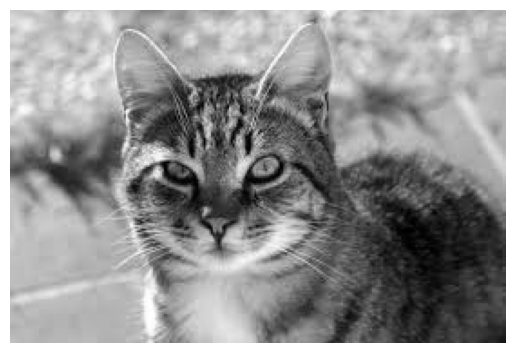

In [76]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("output_gray.png")
plt.imshow(img, cmap="gray")
plt.axis("off")

# Video Frame Processing Engine

In [141]:
!nvidia-smi
!nvcc --version

Thu Apr 16 05:53:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   70C    P0             31W /   70W |     109MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [142]:
!pip install opencv-python numba matplotlib

In [143]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64
import numpy as np
import cv2

def capture_frame():
    display(Javascript("""
    async function capture() {
      const video = document.createElement('video');
      const stream = await navigator.mediaDevices.getUserMedia({ video: true });
      video.srcObject = stream;
      await video.play();

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks()[0].stop();

      return canvas.toDataURL('image/jpeg', 0.8);
    }
    capture();
    """))

    data = eval_js("capture()")
    binary = base64.b64decode(data.split(',')[1])
    img = np.frombuffer(binary, dtype=np.uint8)
    frame = cv2.imdecode(img, cv2.IMREAD_COLOR)
    return frame

In [146]:
from numba import cuda
import numpy as np

@cuda.jit
def rgb_to_gray_cuda(img, gray):
    y, x = cuda.grid(2)   # ✅ correct order

    if y < img.shape[0] and x < img.shape[1]:
        r = img[y, x, 2]
        g = img[y, x, 1]
        b = img[y, x, 0]

        gray[y, x] = np.uint8(0.299 * r + 0.587 * g + 0.114 * b)

In [147]:
def process_frame_cuda(frame):
    h, w, _ = frame.shape

    # Host arrays
    gray = np.zeros((h, w), dtype=np.uint8)

    # Device arrays
    d_frame = cuda.to_device(frame)
    d_gray = cuda.to_device(gray)

    threads = (16, 16)
    blocks = (
        (h + threads[0] - 1) // threads[0],
        (w + threads[1] - 1) // threads[1]
    )

    # ✅ Proper kernel launch
    rgb_to_gray_cuda[blocks, threads](d_frame, d_gray)

    # ✅ Synchronize to catch errors early
    cuda.synchronize()

    return d_gray.copy_to_host()

In [148]:
from numba import cuda
import numpy as np

@cuda.jit
def rgb_to_gray_cuda(img, gray):
    y, x = cuda.grid(2)

    if y >= img.shape[0] or x >= img.shape[1]:
        return

    b = img[y, x, 0]
    g = img[y, x, 1]
    r = img[y, x, 2]

    gray[y, x] = np.uint8(0.299 * r + 0.587 * g + 0.114 * b)

In [150]:
def process_frame_cuda(frame):
    frame = np.ascontiguousarray(frame, dtype=np.uint8)

    h, w, _ = frame.shape
    gray = np.zeros((h, w), dtype=np.uint8)

    d_frame = cuda.to_device(frame)
    d_gray = cuda.to_device(gray)

    threads = (16, 16)
    blocks = (
        (h + threads[0] - 1) // threads[0],
        (w + threads[1] - 1) // threads[1]
    )

    # ✅ CORRECT kernel launch (THIS WAS MISSING)
    rgb_to_gray_cuda[blocks, threads](d_frame, d_gray)

    cuda.synchronize()  # catch errors here

    return d_gray.copy_to_host()

In [152]:
!pip install cupy-cuda12x

In [153]:
import cupy as cp
print(cp.cuda.runtime.getDeviceCount())

1


In [157]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64
import numpy as np
import cv2

def capture_frame():
    js_code = """
    async function capture() {
        const video = document.createElement('video');
        const stream = await navigator.mediaDevices.getUserMedia({ video: true });

        video.srcObject = stream;
        await video.play();

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        const ctx = canvas.getContext('2d');
        ctx.drawImage(video, 0, 0);

        // Stop webcam
        stream.getTracks().forEach(track => track.stop());

        return canvas.toDataURL('image/jpeg', 0.8);
    }
    capture();
    """
    display(Javascript(js_code))

    data = eval_js("capture()")
    binary = base64.b64decode(data.split(',')[1])
    img = np.frombuffer(binary, dtype=np.uint8)
    frame = cv2.imdecode(img, cv2.IMREAD_COLOR)

    return frame

In [158]:
frame = capture_frame()
print(frame.shape)

<IPython.core.display.Javascript object>

(480, 640, 3)


In [159]:
!pip install cupy-cuda12x

In [160]:
import cupy as cp
import numpy as np

def process_frame_cupy(frame):
    # Move frame from CPU → GPU
    gpu_frame = cp.asarray(frame, dtype=cp.float32)

    # BGR → Grayscale on GPU
    gray_gpu = (
        0.114 * gpu_frame[:, :, 0] +
        0.587 * gpu_frame[:, :, 1] +
        0.299 * gpu_frame[:, :, 2]
    )

    # Convert back to uint8 and return to CPU
    return cp.asnumpy(gray_gpu.astype(cp.uint8))

In [161]:
gray_gpu = process_frame_cupy(frame)
print("✅ GPU processing done")

CUDARuntimeError: cudaErrorIllegalAddress: an illegal memory access was encountered

NameError: name 'gray_gpu' is not defined

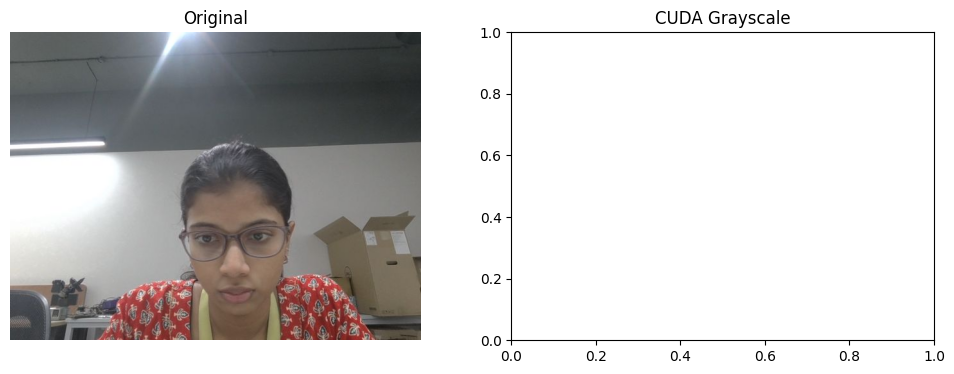

In [129]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("CUDA Grayscale")
plt.imshow(gray_gpu, cmap="gray")
plt.axis("off")

plt.show()

# Motion Detection

In [173]:
!nvidia-smi

Thu Apr 16 06:11:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P0             30W /   70W |     109MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [174]:
!pip install -q pytube ultralytics opencv-python torch torchvision tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 14.5 MB/s eta 0:00:00


In [176]:
from pytube import YouTube

url = "https://www.youtube.com/watch?v=HJAE5Pk8Nyw"
yt = YouTube(url)
stream = yt.streams.filter(progressive=True, file_extension='mp4').first()
video_path = stream.download(filename="input.mp4")

print("Downloaded to:", video_path)

HTTPError: HTTP Error 400: Bad Request